Using files:
  TRIAL: /content/COCOA_VO_P3b_trial_features_with_meta.csv
  SUBJ : /content/COCOA_VO_P3b_subject_features_with_meta.csv

Loaded:
  trial: (7677, 90)
  subj : (98, 83)

FS6 distribution (subject-level unique):
[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]

FS6-ONLY RESULTS (trial-level) — MixedLM if stable, else OLS with subject-clustered SEs

[HH12] Small household size
  Mode        : MEAN
  Model type  : MixedLM(powell)
  Rows used   : 356
  Subjects    : 23
  Formula     : y_uv ~ fs_score_6item + Subjective_SES + C(Highest_Edu)
  Term        : fs_score_6item
  b (µV/FS6)  : +1.2935
  SE          : 0.3822
  95% CI      : [+0.5443, +2.0426]
  p-value     : 0.00071382

[BA] Bachelor’s degree education
  Mode        : MEAN
  Model type  : MixedLM(powell)
  Rows used   : 307
  Subjects    : 19
  Formula     : y_uv ~ fs_score_6item + Subjective_SES
  Term        : fs_score_6item
  b (µV/FS6)  : +1.1292
  SE          : 0.5355
  95% CI      : [+0.0795, +2.1789]
  p-value     : 0.034988

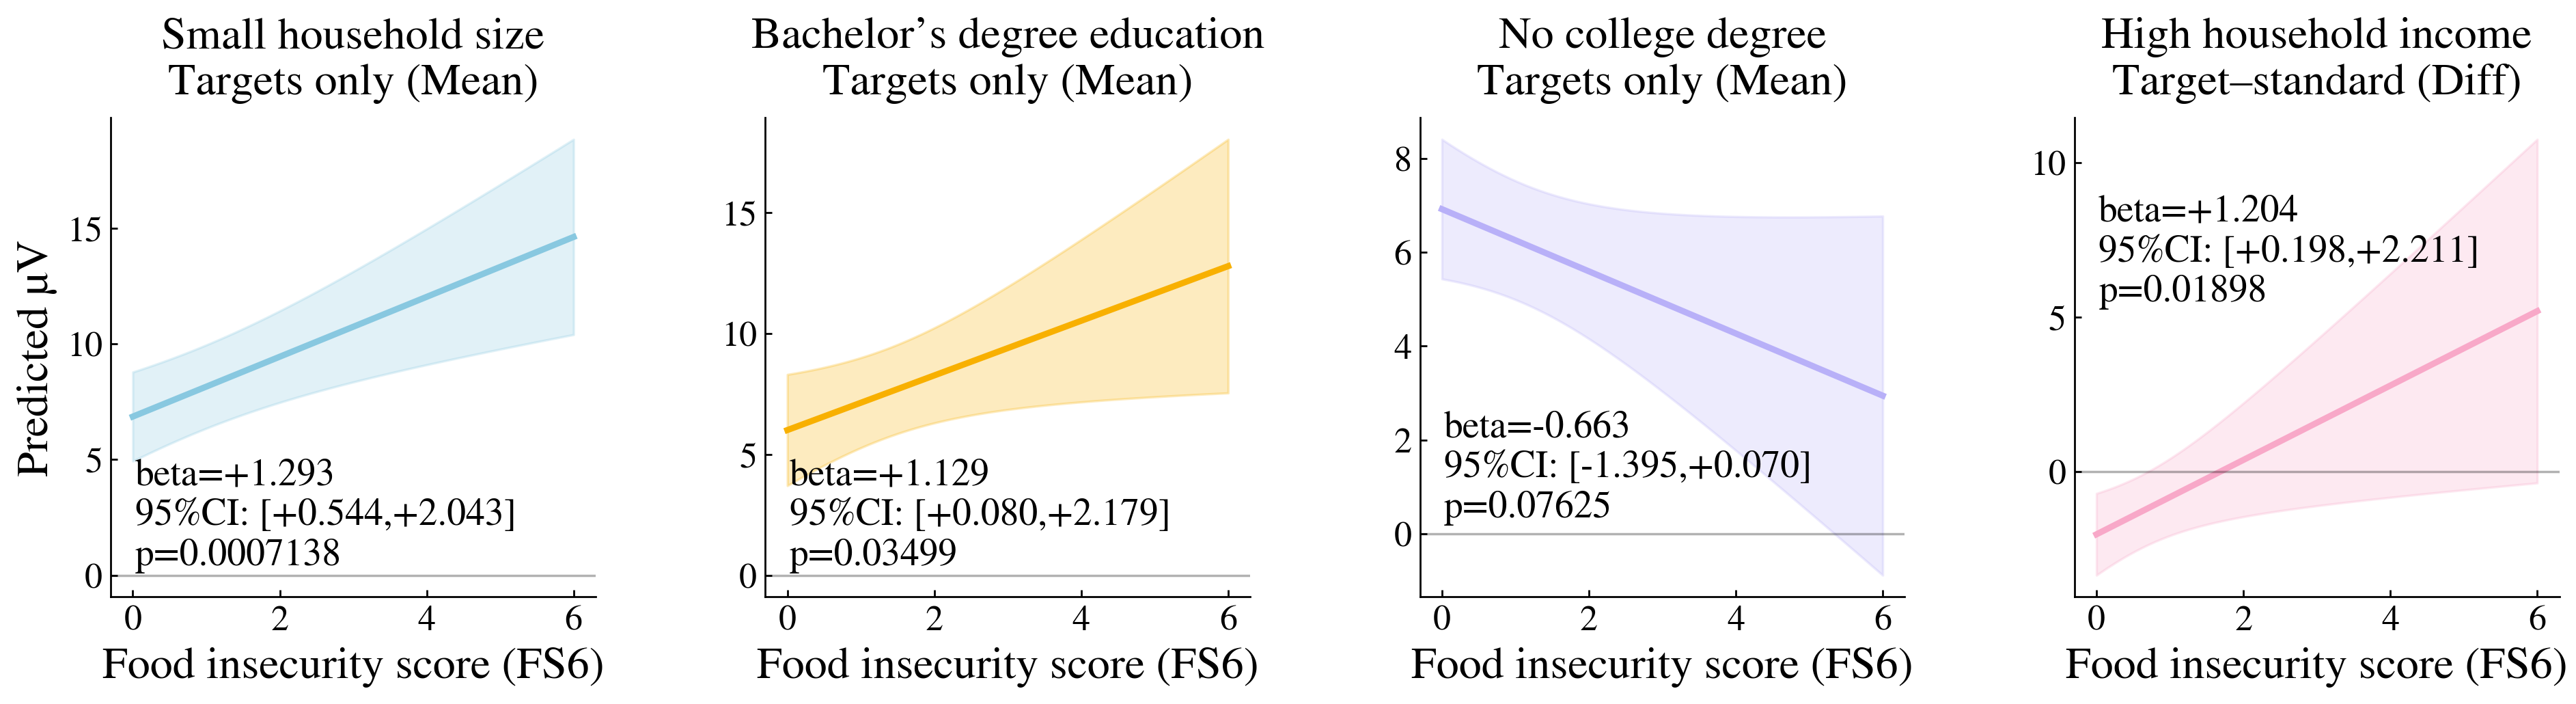


Saved PDF: FS6_only_4effects_mixedlm_grid.pdf


In [ ]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import patsy
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.unicode_minus": False,
})

# FILES
TRIAL_CANDIDATES = [
    "COCOA_VO_P3b_trial_features_with_meta.csv",
]
SUBJ_CANDIDATES = [
    "COCOA_VO_P3b_subject_features_with_meta.csv",
]

def find_first_existing(cands):
    for base in ["/content", "/mnt/data", "."]:
        for c in cands:
            p = os.path.join(base, c)
            if os.path.exists(p):
                return p
    for c in cands:
        hits = glob.glob(f"**/{c}", recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(f"Could not find any of: {cands}")

TRIAL_CSV = find_first_existing(TRIAL_CANDIDATES)
SUBJ_CSV  = find_first_existing(SUBJ_CANDIDATES)

print("Using files:")
print("  TRIAL:", TRIAL_CSV)
print("  SUBJ :", SUBJ_CSV)

trial = pd.read_csv(TRIAL_CSV)
subj0 = pd.read_csv(SUBJ_CSV)

print("\nLoaded:")
print("  trial:", trial.shape)
print("  subj :", subj0.shape)

# HELPERS
def _lower(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().lower()

def income_to_midpoint(s):
    if pd.isna(s):
        return np.nan
    s = str(s).lower().replace("$","").replace(",","").strip()

    if "less than" in s:
        nums = [int(x) for x in re.findall(r"\d+", s)]
        return nums[0] / 2 if nums else np.nan

    if "or more" in s:
        nums = [int(x) for x in re.findall(r"\d+", s)]
        return float(nums[0]) if nums else np.nan

    if "-" in s:
        parts = [p.strip() for p in s.split("-")]
        try:
            lo = int(re.findall(r"\d+", parts[0])[0])
            hi = int(re.findall(r"\d+", parts[1])[0])
            return (lo + hi) / 2
        except Exception:
            return np.nan

    return np.nan

def add_fs_scores(df):
    df = df.copy()

    for c in ["fs1","fs2","fs3","fs4","fs5","fs6"]:
        if c in df.columns:
            df[c] = df[c].map(_lower)

    map_fs12 = {"often true": 1, "sometimes true": 1, "never true": 0}
    map_yesno = {"yes": 1, "no": 0}

    df["fs1_bin"] = df["fs1"].map(map_fs12)
    df["fs2_bin"] = df["fs2"].map(map_fs12)
    df["fs3_bin"] = df["fs3"].map(map_yesno)
    df["fs5_bin"] = df["fs5"].map(map_yesno)
    df["fs6_bin"] = df["fs6"].map(map_yesno)

    df["fs_score_5item"] = df[["fs1_bin","fs2_bin","fs3_bin","fs5_bin","fs6_bin"]].sum(axis=1)

    fs4_pos = {"almost every month", "some months but not every month"}
    df["fs4_bin"] = np.where(df["fs4"].isin(fs4_pos), 1.0, 0.0)

    df["fs_score_6item"] = df["fs_score_5item"] + df["fs4_bin"]
    return df

def add_bins_and_income(trial_df):
    d = trial_df.copy()

    if "Income" in d.columns:
        d["income_mid"] = d["Income"].apply(income_to_midpoint)
    if "Income_Household" in d.columns:
        d["hh_income_mid"] = d["Income_Household"].apply(income_to_midpoint)

    if "Household_Members" in d.columns:
        d["Household_Members"] = pd.to_numeric(d["Household_Members"], errors="coerce")
        d["Household_bin"] = pd.cut(
            d["Household_Members"],
            bins=[0,2,4,100],
            labels=["1-2","3-4","5+"]
        )
    return d

def add_hh_income_tertile_by_subject(trial_df):
    base = trial_df[["subject","hh_income_mid"]].drop_duplicates("subject").copy()
    base["hh_income_mid"] = pd.to_numeric(base["hh_income_mid"], errors="coerce")
    base = base.dropna(subset=["hh_income_mid"])
    if base["hh_income_mid"].nunique() < 3:
        trial_df["HHIncome_tertile"] = pd.Series([np.nan]*len(trial_df), index=trial_df.index)
        return trial_df

    base["HHIncome_tertile"] = pd.qcut(base["hh_income_mid"], 3, duplicates="drop")
    out = trial_df.merge(base[["subject","HHIncome_tertile"]], on="subject", how="left")
    return out

def ensure_is_target_01(d):
    d = d.copy()
    if "is_target_01" in d.columns:
        return d
    if "is_target" in d.columns:
        if d["is_target"].dtype == bool:
            d["is_target_01"] = d["is_target"].astype(int)
        else:
            s = d["is_target"].astype(str).str.lower()
            d["is_target_01"] = np.where(s.isin(["true","1","yes"]), 1, 0)
        return d
    raise KeyError("Need either is_target_01 or is_target in the trial file.")

def choose_y_uv(d):
    for c in ["pz_mean_300_600_uv", "p3b_mean_uv", "roi_mean_300_600_uv"]:
        if c in d.columns:
            return c
    if "roi_mean_300_600" in d.columns:
        d["y_uv"] = pd.to_numeric(d["roi_mean_300_600"], errors="coerce") * 1e6
        return "y_uv"
    raise KeyError("Could not find a usable P3b mean amplitude column.")

# BUILD trial3 with everything needed
trial3 = trial.copy()

for req in ["subject", "Highest_Edu", "Subjective_SES"]:
    if req not in trial3.columns:
        raise KeyError(f"Missing required column in trial CSV: {req}")

trial3 = add_fs_scores(trial3)
trial3 = add_bins_and_income(trial3)
trial3 = add_hh_income_tertile_by_subject(trial3)
trial3 = ensure_is_target_01(trial3)

ycol = choose_y_uv(trial3)
if ycol != "y_uv":
    trial3["y_uv"] = pd.to_numeric(trial3[ycol], errors="coerce")

trial3["Subjective_SES"] = pd.to_numeric(trial3["Subjective_SES"], errors="coerce")

print("\nFS6 distribution (subject-level unique):")
tmp_fs = trial3[["subject","fs_score_6item"]].drop_duplicates("subject")
print(sorted(tmp_fs["fs_score_6item"].dropna().unique().tolist()))

# MODEL FIT
def clean_for_formula(d, formula):
    tokens = re.findall(r"[A-Za-z_][A-Za-z0-9_]*", formula)
    needed = sorted(set([t for t in tokens if t not in ["C"]]))
    needed = [c for c in needed if c in d.columns]
    return d.dropna(subset=needed).copy()

def fit_mixed_or_clustered_ols(d, formula, label):
    """
    MixedLM random intercept by subject:
      - clean_for_formula (same as strict code)
      - try lbfgs then powell
      - maxiter=400
      - require converged
      - require finite/stable cov_params
    If still fails, fall back to OLS with subject-clustered SE.
    Returns (result, model_type_str, cleaned_df).
    """
    d = clean_for_formula(d, formula)

    if d["subject"].nunique() < 2:
        ols = smf.ols(formula, data=d).fit(cov_type="HC3")
        return ols, "OLS(HC3)", d

    try:
        md = smf.mixedlm(formula, data=d, groups=d["subject"], re_formula="1")

        last_err = None
        for method in ["lbfgs", "powell"]:
            try:
                r = md.fit(reml=False, method=method, maxiter=400, disp=False)

                if hasattr(r, "converged") and (not bool(r.converged)):
                    last_err = RuntimeError(f"did not converge ({method})")
                    continue

                cov = np.asarray(r.cov_params())
                if (not np.isfinite(cov).all()) or (np.nanmax(np.abs(cov)) > 1e12):
                    last_err = RuntimeError("unstable covariance")
                    continue

                return r, f"MixedLM({method})", d

            except Exception as e:
                last_err = e
                continue

        ols = smf.ols(formula, data=d).fit(
            cov_type="cluster",
            cov_kwds={"groups": d["subject"]}
        )
        return ols, "OLS(cluster-subject)", d

    except Exception:
        ols = smf.ols(formula, data=d).fit(
            cov_type="cluster",
            cov_kwds={"groups": d["subject"]}
        )
        return ols, "OLS(cluster-subject)", d

# DEFINE THE 4 EFFECTS
def edu_match(series, needle):
    s = series.astype(str).str.lower().str.strip()
    return s.str.contains(needle, na=False)

TITLES = {
    "HH12":  "Small household size",
    "BA":    "Bachelor’s degree education",
    "NoDeg": "No college degree",
    "HHHi":  "High household income",
}

COLORS = {
    "HH12":  "#88C8E0",
    "BA":    "#F8B000",
    "NoDeg": "#B8B0F8",
    "HHHi":  "#F8A8C8",
}

effects = []

# HH12 targets-only (Mean)
d1 = trial3[(trial3["Household_bin"].astype(str) == "1-2") & (trial3["is_target_01"] == 1)].copy()
f1 = "y_uv ~ fs_score_6item + Subjective_SES"
if d1["Highest_Edu"].nunique(dropna=True) >= 2:
    f1 += " + C(Highest_Edu)"
r1, m1, d1c = fit_mixed_or_clustered_ols(d1, f1, "HH12")
effects.append(("HH12", "Targets only (Mean)", "fs_score_6item", r1, f1, d1c, "MEAN", m1))

# BA targets-only (Mean)
d2 = trial3[edu_match(trial3["Highest_Edu"], "bachelor") & (trial3["is_target_01"] == 1)].copy()
f2 = "y_uv ~ fs_score_6item + Subjective_SES"
r2, m2, d2c = fit_mixed_or_clustered_ols(d2, f2, "BA")
effects.append(("BA", "Targets only (Mean)", "fs_score_6item", r2, f2, d2c, "MEAN", m2))

# NoDeg targets-only (Mean)
d3 = trial3[edu_match(trial3["Highest_Edu"], "no degree") & (trial3["is_target_01"] == 1)].copy()
f3 = "y_uv ~ fs_score_6item + Subjective_SES"
r3, m3, d3c = fit_mixed_or_clustered_ols(d3, f3, "NoDeg")
effects.append(("NoDeg", "Targets only (Mean)", "fs_score_6item", r3, f3, d3c, "MEAN", m3))

# HHHi all trials (Diff via interaction)
hhcats = trial3["HHIncome_tertile"].dropna().cat.categories
HHHI_LEVEL = hhcats[-1] if len(hhcats) else None

d4 = trial3[(trial3["HHIncome_tertile"] == HHHI_LEVEL)].copy() if HHHI_LEVEL is not None else trial3.iloc[0:0].copy()
f4 = "y_uv ~ is_target_01 * fs_score_6item + Subjective_SES"
if d4["Highest_Edu"].nunique(dropna=True) >= 2:
    f4 += " + C(Highest_Edu)"
r4, m4, d4c = fit_mixed_or_clustered_ols(d4, f4, "HHHi")
effects.append(("HHHi", "Target–standard (Diff)", "fs_score_6item", r4, f4, d4c, "DIFF", m4))


# PRINT “CORE NUMBERS” FOR ALL 4
def _as_series(x):
    return x if isinstance(x, pd.Series) else pd.Series(x)

def get_fe_params(res):
    if hasattr(res, "fe_params"):
        return _as_series(res.fe_params)
    return _as_series(res.params)

def get_fe_cov(res, fe_names):
    cov = res.cov_params()
    if isinstance(cov, np.ndarray):
        idx = list(get_fe_params(res).index)
        cov = pd.DataFrame(cov, index=idx, columns=idx)
    else:
        cov = cov.copy()
    fe_names = [n for n in fe_names if n in cov.index]
    return cov.loc[fe_names, fe_names]

def design_matrix(res, new_df):
    di = res.model.data.design_info
    X = patsy.build_design_matrices([di], new_df)[0]
    return pd.DataFrame(np.asarray(X), columns=di.column_names)

def find_interaction_name(res, a, b):
    names = list(get_fe_params(res).index)
    c1 = f"{a}:{b}"
    c2 = f"{b}:{a}"
    if c1 in names: return c1
    if c2 in names: return c2
    return c1

def coef_table(res, term):
    fe = get_fe_params(res)
    if term not in fe.index:
        return dict(b=np.nan,se=np.nan,lo=np.nan,hi=np.nan,p=np.nan)

    b = float(fe[term])
    cov = get_fe_cov(res, fe.index.tolist())
    se = np.nan
    if term in cov.index and np.isfinite(cov.loc[term, term]):
        se = float(np.sqrt(max(cov.loc[term, term], 0.0)))

    lo = b - 1.96*se if np.isfinite(se) else np.nan
    hi = b + 1.96*se if np.isfinite(se) else np.nan

    p = np.nan
    if hasattr(res, "pvalues") and res.pvalues is not None:
        try:
            p = float(res.pvalues[term])
        except Exception:
            p = np.nan

    return dict(b=b,se=se,lo=lo,hi=hi,p=p)

print("\n" + "="*100)
print("FS6-ONLY RESULTS (trial-level) — MixedLM if stable, else OLS with subject-clustered SEs")
print("="*100)

for (lab, subtitle, xcol, res, f_used, dclean, mode, mtype) in effects:
    n_rows = int(dclean.shape[0])
    n_subj = int(dclean["subject"].nunique())

    term = xcol if mode != "DIFF" else find_interaction_name(res, "is_target_01", xcol)
    ct = coef_table(res, term)

    print(f"\n[{lab}] {TITLES.get(lab, lab)}")
    print(f"  Mode        : {mode}")
    print(f"  Model type  : {mtype}")
    print(f"  Rows used   : {n_rows}")
    print(f"  Subjects    : {n_subj}")
    print(f"  Formula     : {f_used}")
    print(f"  Term        : {term}")
    print(f"  b (µV/FS6)  : {ct['b']:+.4f}")
    if np.isfinite(ct["se"]):
        print(f"  SE          : {ct['se']:.4f}")
        print(f"  95% CI      : [{ct['lo']:+.4f}, {ct['hi']:+.4f}]")
    if np.isfinite(ct["p"]):
        print(f"  p-value     : {ct['p']:.6g}")

# PREDICTION LINES + 95% CI (fixed effects only)
def pred_ci_fixed(res, new_df):
    fe = get_fe_params(res)
    cov = get_fe_cov(res, fe.index.tolist())

    X = design_matrix(res, new_df)
    cols = [c for c in X.columns if c in fe.index]
    X = X[cols]
    b = fe[cols].to_numpy(dtype=float)
    V = cov.loc[cols, cols].to_numpy(dtype=float)

    pred = (X.to_numpy(dtype=float) @ b).ravel()
    var  = np.sum((X.to_numpy(dtype=float) @ V) * X.to_numpy(dtype=float), axis=1)
    se   = np.sqrt(np.maximum(var, 0))
    lo   = pred - 1.96 * se
    hi   = pred + 1.96 * se
    return pred, lo, hi

def pred_ci_diff_fixed(res, base_df, is_target_col="is_target_01"):
    fe = get_fe_params(res)
    cov = get_fe_cov(res, fe.index.tolist())

    df_t = base_df.copy()
    df_s = base_df.copy()
    df_t[is_target_col] = 1
    df_s[is_target_col] = 0

    X_t = design_matrix(res, df_t)
    X_s = design_matrix(res, df_s)
    X_d = X_t - X_s

    cols = [c for c in X_d.columns if c in fe.index]
    X_d = X_d[cols]
    b = fe[cols].to_numpy(dtype=float)
    V = cov.loc[cols, cols].to_numpy(dtype=float)

    pred = (X_d.to_numpy(dtype=float) @ b).ravel()
    var  = np.sum((X_d.to_numpy(dtype=float) @ V) * X_d.to_numpy(dtype=float), axis=1)
    se   = np.sqrt(np.maximum(var, 0))
    lo   = pred - 1.96 * se
    hi   = pred + 1.96 * se
    return pred, lo, hi

import textwrap

def set_wrapped_xlabel(ax, label, fontsize=20, max_chars_per_line=18, max_lines=2):
    wrapped = "\n".join(textwrap.wrap(label, width=max_chars_per_line))
    wrapped = "\n".join(wrapped.split("\n")[:max_lines])

    ax.set_xlabel(wrapped, fontsize=fontsize, labelpad=10)
    ax.xaxis.label.set_horizontalalignment("center")
    ax.xaxis.set_label_coords(0.5, -0.14)

# 1x4 PLOT + SAVE PDF
fig, axes = plt.subplots(1, 4, figsize=(18.5, 4.6), dpi=250, sharey=False)
fig.subplots_adjust(wspace=0.35, top=0.83, bottom=0.22)

for ax, (lab, subtitle, xcol, res, formula_used, dclean, mode, mtype) in zip(axes, effects):
    color = COLORS.get(lab, "#8ecae6")

    mean_ses = None
    if "Subjective_SES" in dclean.columns and pd.to_numeric(dclean["Subjective_SES"], errors="coerce").notna().any():
        mean_ses = float(pd.to_numeric(dclean["Subjective_SES"], errors="coerce").mean())

    mode_edu = None
    if "Highest_Edu" in dclean.columns and dclean["Highest_Edu"].dropna().size > 0:
        mode_edu = dclean["Highest_Edu"].dropna().mode().iloc[0]

    xgrid = np.linspace(0, 6, 121)

    base = pd.DataFrame({xcol: xgrid})
    if ("Subjective_SES" in formula_used) and (mean_ses is not None):
        base["Subjective_SES"] = mean_ses
    if ("C(Highest_Edu)" in formula_used) and (mode_edu is not None):
        base["Highest_Edu"] = mode_edu

    if mode != "DIFF":
        pred, lo, hi = pred_ci_fixed(res, base)
        term = xcol
    else:
        pred, lo, hi = pred_ci_diff_fixed(res, base, is_target_col="is_target_01")
        term = find_interaction_name(res, "is_target_01", xcol)

    ax.plot(xgrid, pred, linewidth=2.6, color=color)

    ax.fill_between(xgrid, lo, hi, color=color, alpha=0.25)

    ax.set_title(f"{TITLES.get(lab, lab)}\n{subtitle}", fontsize=19, pad=10)

    ct = coef_table(res, term)
    rows_txt = f"trials={int(dclean.shape[0])}"

    if np.isfinite(ct["b"]) and np.isfinite(ct["se"]):
        txt = (
            f"beta={ct['b']:+.3f}\n"
            f"95%CI: [{ct['lo']:+.3f},{ct['hi']:+.3f}]"
        )
    elif np.isfinite(ct["b"]):
        txt = f"{rows_txt}\nb={ct['b']:+.3f}"
    else:
        txt = f"{rows_txt}\nb=NA"

    if np.isfinite(ct["p"]):
        txt += f"\np={ct['p']:.4g}"

    x_text, y_text = 0.05, 0.05
    if lab == "NoDeg":
        x_text, y_text = 0.05, 0.15
    if lab == "HHHi":
        x_text, y_text = 0.05, 0.60


    ax.text(
        x_text, y_text, txt,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=16
    )

    ax.axhline(0, color="black", linewidth=1.0, alpha=0.30)
    ax.set_xlabel("Food insecurity score (FS6)", fontsize=19)
    if ax is axes[0]:
        ax.set_ylabel("Predicted µV", fontsize=19)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


    for ax in axes:
        ax.tick_params(axis="both", which="major", labelsize=15)

out_pdf = "FS6_only_4effects_mixedlm_grid.pdf"
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

print("\nSaved PDF:", out_pdf)
